# Variable Relationships: Covariance, Correlation

Compare covariance, correlation, and regression for relationships between variables. Covers interpretation, assumptions, pitfalls, and Python examples.


## 1. Relationships between Variables: Understanding How Data Moves Together

Understanding how variables relate to one another is fundamental to data science and statistical analysis. Whether we're exploring patterns in data, building predictive models, or testing hypotheses, the ability to quantify and interpret relationships between variables enables us to extract meaningful insights from complex datasets and make informed decisions based on empirical evidence.

## 2. Introduction

In real-world data, variables rarely exist in isolation. Customer age might relate to purchasing behavior, temperature might affect sales patterns, and education level might correlate with income. Recognizing and quantifying these relationships forms the backbone of exploratory data analysis, predictive modeling, and causal inference.

This notebook explores the fundamental tools for measuring and interpreting relationships between variables. We begin with covariance and correlation, which quantify the strength and direction of linear associations. We then examine regression analysis (superficially as we have a whole notebook dedicated to it), which models these relationships explicitly to enable prediction and inference. Finally, we address one of the most important distinctions in data science: the difference between correlation and causation. Understanding when an observed association reflects a causal mechanism rather than a spurious correlation helps avoid misinterpretation and supports sound conclusions.

By the end of this notebook, you'll understand how to measure variable relationships, model them mathematically, interpret them correctly, and recognize the boundaries of what these methods can tell us about the underlying data-generating process.

## 3. Covariance: Measuring Joint Variability

Covariance quantifies how two variables change together. When one variable tends to be above its mean at the same time the other is above its mean, they have positive covariance. When one tends to be above its mean while the other is below its mean, they have negative covariance. A covariance near zero suggests little linear relationship between the variables.

The population Covariance between two Variables $X$ and $Y$ is defined as:

$$ Cov(X,Y) - E[(X - \mu_X)(Y - \mu_Y)]$$

where 
1. $E[.]$: Expected Value operator
2. $mu_X$ : $E[X]$: Population mean of $X$ 
3. $mu_Y$ : $E[Y]$: Population mean of $Y$ 

In practice, we work with sample data and estimate covariance using the sample covariance:


$$s_XY = (1 / n - 1) * \sum_{i=1}^{n}{x_{i} - \hat{x}}{y_{i} - \hat{y}}$$

where 
1. n: sample size
2. $x_i,y_i$ : individual obeservations
3. $\hat(x),\hat(y)$: Sample means

The interpretation of covariance is straightforward in terms of direction: positive values indicate variables tend to move together in the same direction, while negative values indicate they move in opposite directions. However, the magnitude of covariance is difficult to interpret because it depends on the units and scales of the variables. A covariance of 100 might indicate a strong relationship for variables measured in small units, but a weak relationship for variables measured in large units. This limitation motivates the need for a standardized measure of association.

To better understand how covariance captures joint variability, consider the geometric interpretation. Each data point contributes to the covariance based on whether both variables are above their means (positive contribution), both below their means (positive contribution), or one above and one below (negative contribution). The following visualization shows this structure and how different quadrants contribute to the overall covariance measure.

Means:  X = 4.61,  Y = 4.64
Quadrant sums: Q1=145.32, Q2=-12.33, Q3=158.78, Q4=-4.50
Total covariance contribution: 287.28


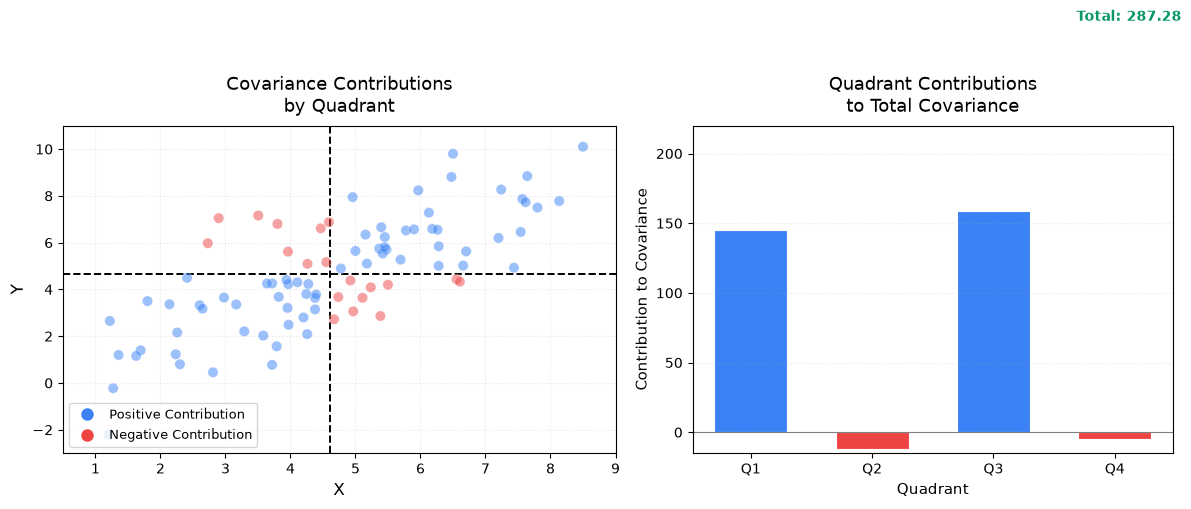

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# Generate Synthetic data that looks like the figure
np.random.seed(42)

#main cluod with positive correlation
n = 80
x = np.random.normal(4.8,1.8,n)
y = 0.9 * x + np.random.normal(0.5, 1.6, n)

extra_x = np.array([1.2, 1.8, 2.3, 6.5, 7.2, 7.8, 8.5, 3.8, 4.2, 5.5])
extra_y = np.array([-2.2, 3.5, 0.8, 9.8, 6.2, 7.5, 10.1, 6.8, 2.8, 4.2])
x = np.concatenate([x,extra_x])
y = np.concatenate([y, extra_y])

# Compute means and pre-point contributions
mean_x = np.mean(x)
mean_y = np.mean(y)


dx = x - mean_x
dy = y - mean_y

# contribution of each point to the (sample) covariance
contrib = dx * dy

#quandrant masks
q1 = (dx > 0) & (dy >0)
q2 = (dx < 0) & (dy >0)
q3 = (dx < 0) & (dy < 0)
q4 = (dx > 0) & (dy < 0)


sum_q1 = contrib[q1].sum()
sum_q2 = contrib[q2].sum()
sum_q3 = contrib[q3].sum()
sum_q4 = contrib[q4].sum()
total_cov = contrib.sum()


print(f"Means:  X = {mean_x:.2f},  Y = {mean_y:.2f}")
print(f"Quadrant sums: Q1={sum_q1:.2f}, Q2={sum_q2:.2f}, Q3={sum_q3:.2f}, Q4={sum_q4:.2f}")
print(f"Total covariance contribution: {total_cov:.2f}")

#Create Figure

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.5),
                               gridspec_kw={'width_ratios': [1.15, 1]})

colors = np.where(contrib >=0 ,'#3b82f6', '#ef4444')   # blue / red)
ax1.scatter(x,y, c=colors,s=55, alpha=0.5, edgecolors ='white', linewidth=0.4,zorder=3)

# Mean lines
ax1.axvline(mean_x, color='black', linestyle='--', linewidth=1.4, zorder=2)
ax1.axhline(mean_y, color='black', linestyle='--', linewidth=1.4, zorder=2)

ax1.set_xlabel('X', fontsize=12)
ax1.set_ylabel('Y', fontsize=12)
ax1.set_title('Covariance Contributions\nby Quadrant', fontsize=13, pad=10)
ax1.set_xlim(0.5, 9)
ax1.set_ylim(-3, 11)
ax1.grid(True, alpha=0.3, linestyle=':')


# Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#3b82f6',
           markersize=10, label='Positive Contribution'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#ef4444',
           markersize=10, label='Negative Contribution')
]
ax1.legend(handles=legend_elements, loc='lower left', frameon=True, fontsize=9)

# ---------- Right: Bar chart ----------
quadrants = ['Q1', 'Q2', 'Q3', 'Q4']
values = [sum_q1, sum_q2, sum_q3, sum_q4]
bar_colors = ['#3b82f6', '#ef4444', '#3b82f6', '#ef4444']

bars = ax2.bar(quadrants, values, color=bar_colors, width=0.6, edgecolor='white', linewidth=0.8)

# Horizontal line for total
ax2.axhline(total_cov, color='#059669', linestyle='--', linewidth=2, label=f'Total: {total_cov:.2f}')
ax2.text(3.55, total_cov + 8, f'Total: {total_cov:.2f}', color='#059669',
         fontsize=10, fontweight='bold', ha='right')

ax2.set_ylabel('Contribution to Covariance', fontsize=11)
ax2.set_xlabel('Quadrant', fontsize=11)
ax2.set_title('Quadrant Contributions\nto Total Covariance', fontsize=13, pad=10)
ax2.set_ylim(-15, 220)
ax2.grid(True, axis='y', alpha=0.3, linestyle=':')
ax2.axhline(0, color='gray', linewidth=0.8)

plt.tight_layout()
plt.savefig("Plots/Covariane_Comparision.png", dpi=150)
plt.show()

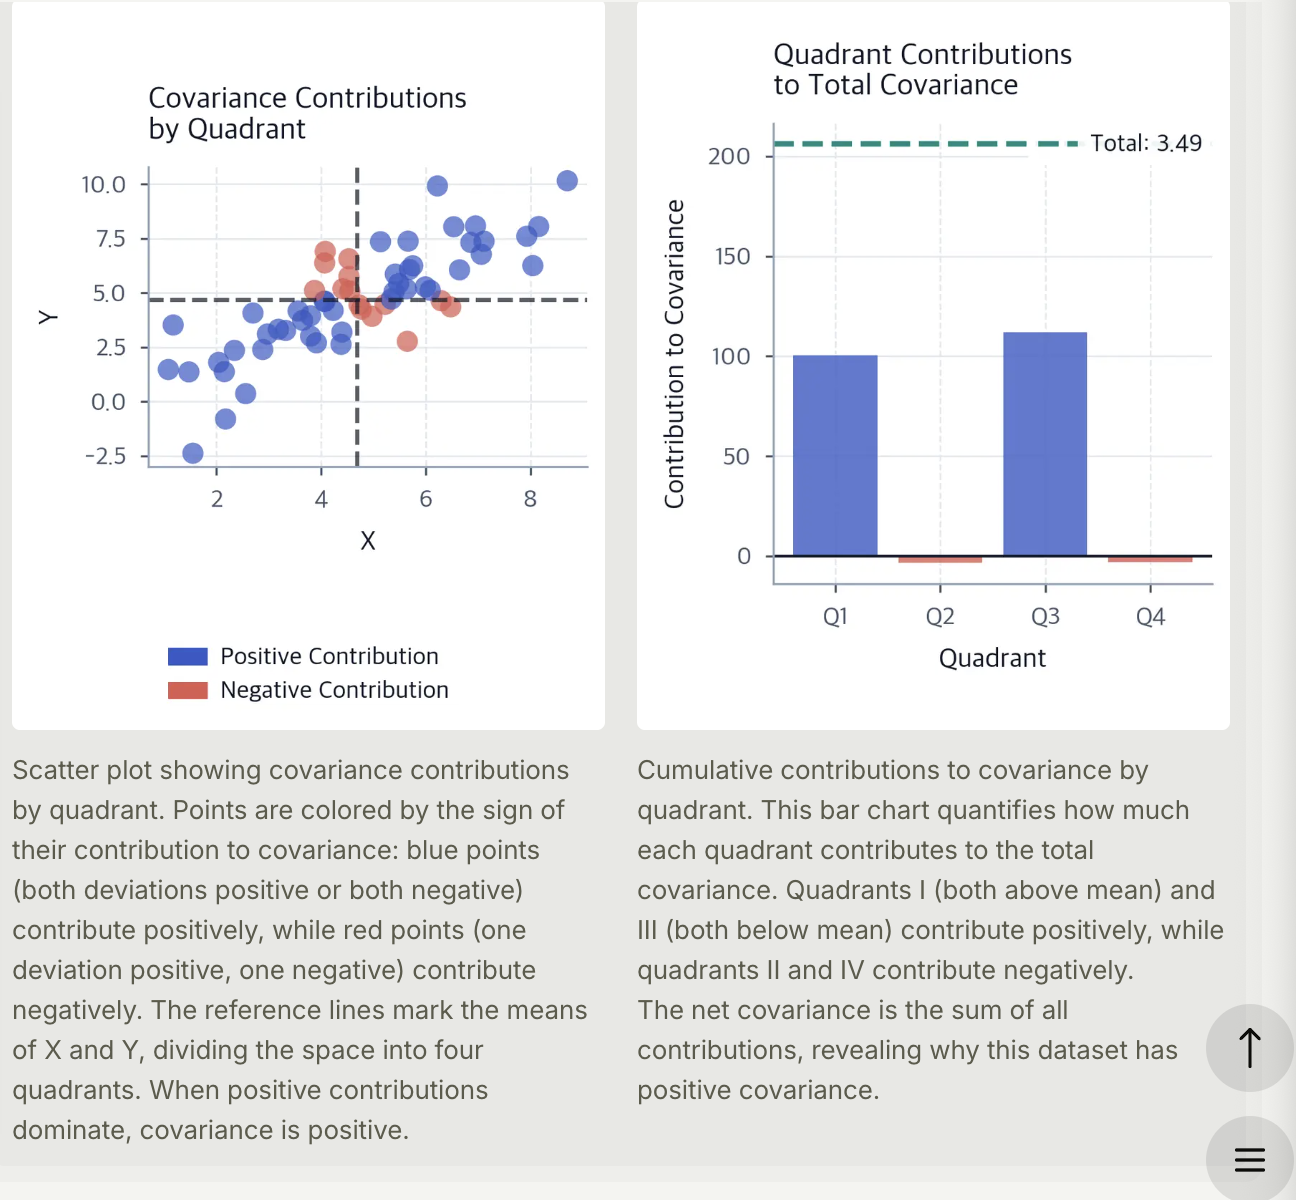

## 4. Correlation: Standardized Reltionship Strength

Correlation addresses the scale-dependence problem of covariance by standardizing the measure. The Pearson correlation coefficient, the most commonly used correlation measure, divides the covariance by the product of the standard deviations of both variables. This normalization ensures that correlation always falls between `-1` and `+1`, regardless of the original units.

The population correlation coefficient is :

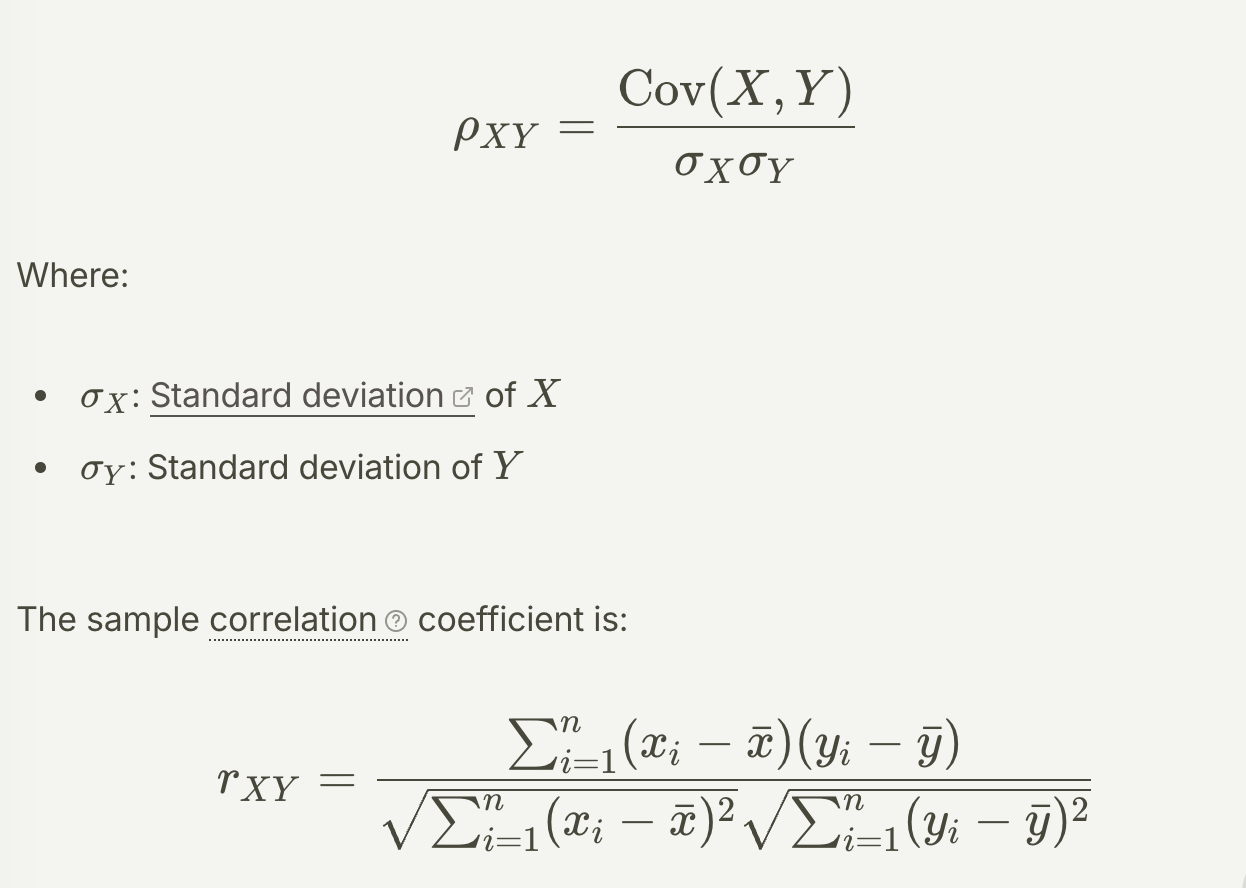

Correlation values have clear interpretations. A correlation of 
`r = 1` indicates a perfect positive linear relationship where all points fall exactly on a line with positive slope. A correlation of 
`r = −1` indicates a perfect negative linear relationship. A correlation of 
`r = 0` suggests no linear relationship, though non-linear relationships may still exist. In practice, correlations between `0.7` and `1.0 or -0.7` and `-1.0` are generally considered strong, `0.3 to 0.7`(or ` -0.3 to -0.7`) moderate, and below `0.3` weak, though these thresholds vary by field and context.

The following visualization demonstrates these different correlation patterns, showing how various relationships between variables manifest in scatter plots and their corresponding correlation coefficients.

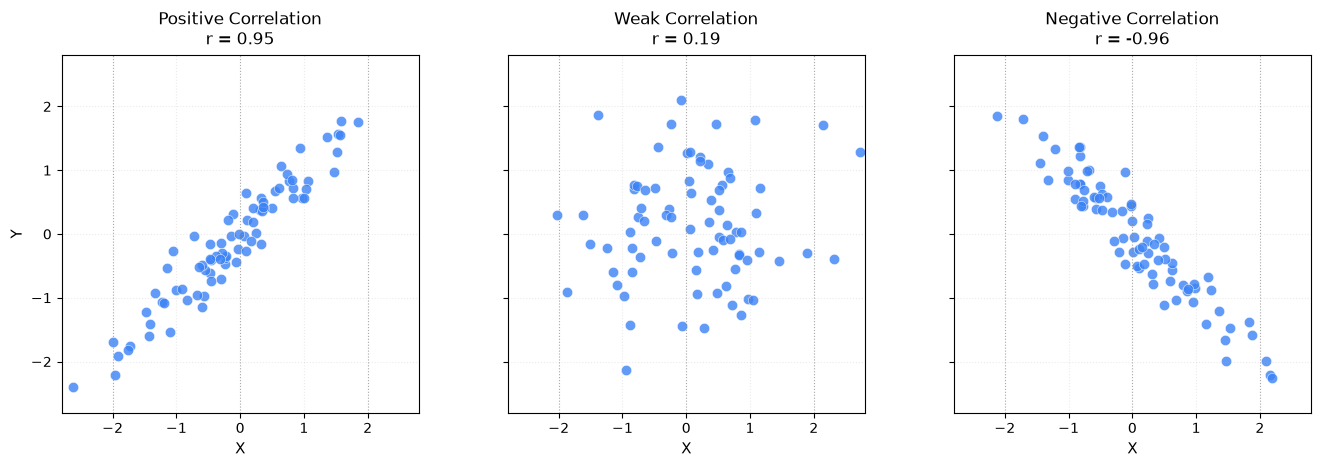

In [5]:
import numpy as np
import matplotlib.pyplot as plt


np.random.seed(42)
n = 80

x1 = np.random.normal(0,1,n)
y1 = 0.95 * x1 + np.random.normal(0,0.3, n)


x2 = np.random.normal(0,1,n)
y2 = 0.19 * x2 + np.random.normal(0,1.0,n)

x3 = np.random.normal(0, 1, n)
y3 = -0.96 * x3 + np.random.normal(0, 0.28, n)


fig, axes = plt.subplots(1,3, figsize=(14,4.5), sharey=True)

datasets = [
    (x1, y1, "Positive Correlation\nr = 0.95", 0.95),
    (x2, y2, "Weak Correlation\nr = 0.19", 0.19),
    (x3, y3, "Negative Correlation\nr = -0.96", -0.96)
]


for ax, (x,y, title, r) in zip(axes, datasets):
    ax.scatter(x,y,c='#3b82f6', s=55, alpha=0.8, edgecolors='white', linewidth=0.4)
    for v in [-2,0,2]:
        ax.axvline(v, color='grey', linestyle=':',linewidth=0.8, alpha=0.6)

        ax.set_xlim(-2.8,2.8)
        ax.set_ylim(-2.8,2.8)
        ax.set_xlabel('X', fontsize=11)
        ax.set_title(title, fontsize=12, pad=8)
        ax.grid(True, alpha=0.25, linestyle=':')
        ax.set_aspect('equal', adjustable='box')

    axes[0].set_ylabel('Y', fontsize=11)

plt.tight_layout()
plt.savefig("Plots/Correlation_Comparision.png", dpi=150)
plt.show()

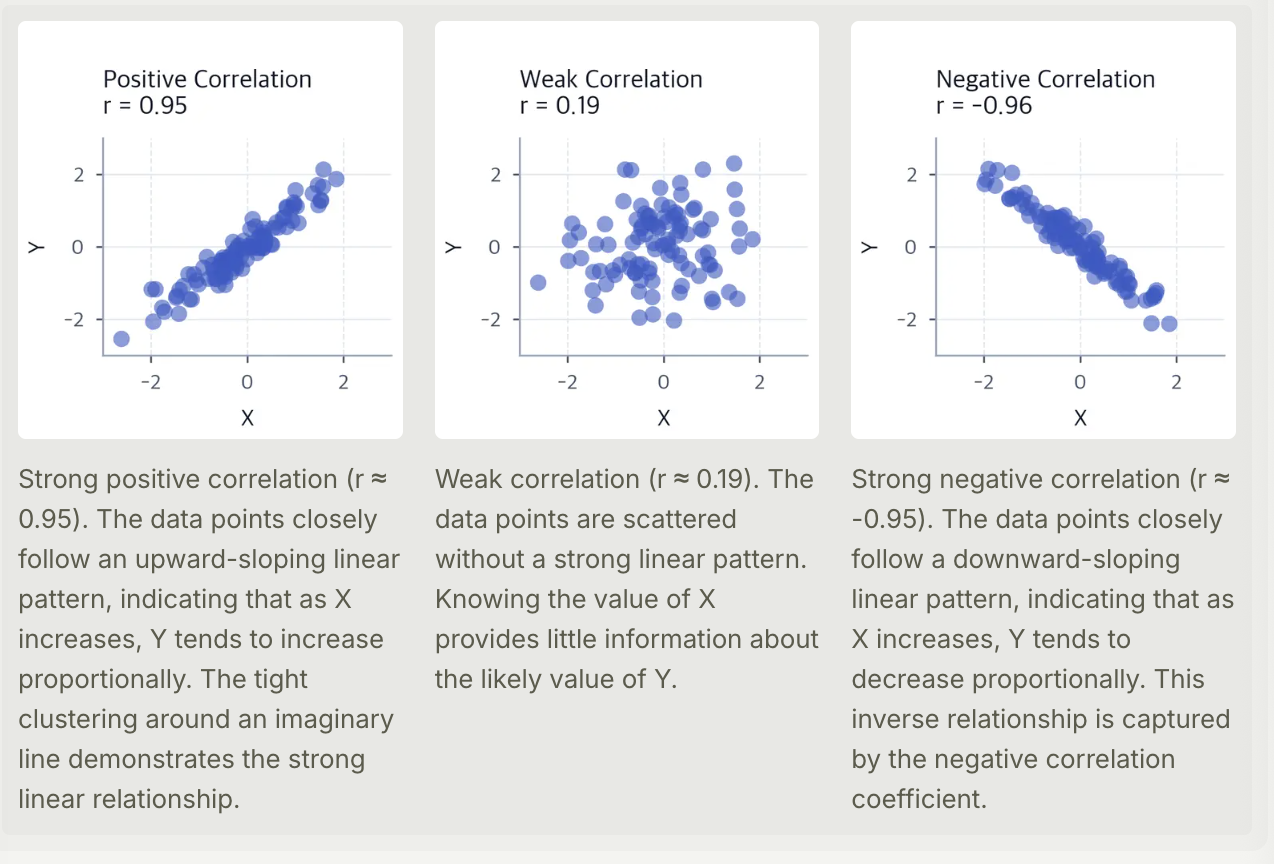

Correlation measures only linear relationships. Two variables can have zero correlation yet still be strongly related through a non-linear pattern such as a quadratic or sinusoidal relationship. This limitation makes visualization essential: plotting your data before relying solely on correlation coefficients helps identify non-linear patterns that correlation cannot detect. The following example demonstrates this limitation with a quadratic relationship where the correlation coefficient is near zero despite a clear pattern.

Pearson r = -0.126


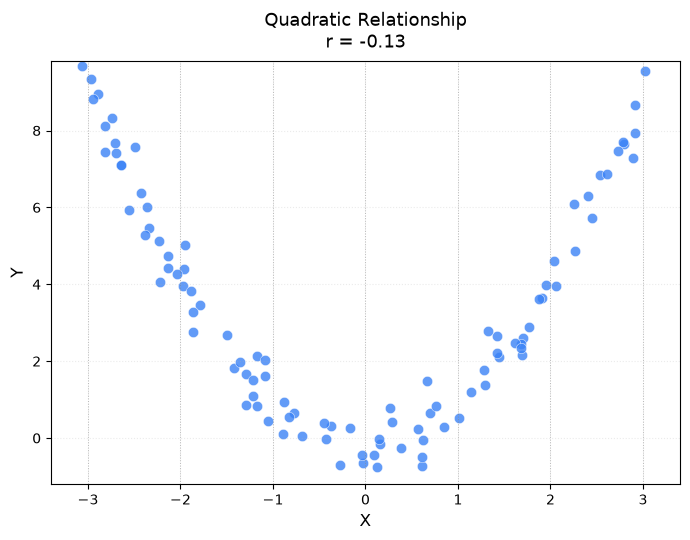

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

np.random.seed(42)

# -------------------------------------------------
# Generate quadratic data with near-zero linear correlation
# -------------------------------------------------
n = 100
x = np.random.uniform(-3.1, 3.1, n)
y = x**2 + np.random.normal(0, 0.55, n)   # parabola + modest noise

r, _ = pearsonr(x, y)
print(f"Pearson r = {r:.3f}")

# -------------------------------------------------
# Plot
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5.5))

ax.scatter(x, y, c='#3b82f6', s=55, alpha=0.8, edgecolors='white', linewidth=0.4)

# Light vertical grid lines (matching the original style)
for v in range(-3, 4):
    ax.axvline(v, color='gray', linestyle=':', linewidth=0.7, alpha=0.5)

ax.set_xlim(-3.4, 3.4)
ax.set_ylim(-1.2, 9.8)
ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('Y', fontsize=12)
ax.set_title(f'Quadratic Relationship\nr = {r:.2f}', fontsize=13, pad=10)
ax.grid(True, alpha=0.25, linestyle=':')

plt.tight_layout()
plt.savefig("Plots/Quadratic_Relationship.png", dpi=150)
plt.show()

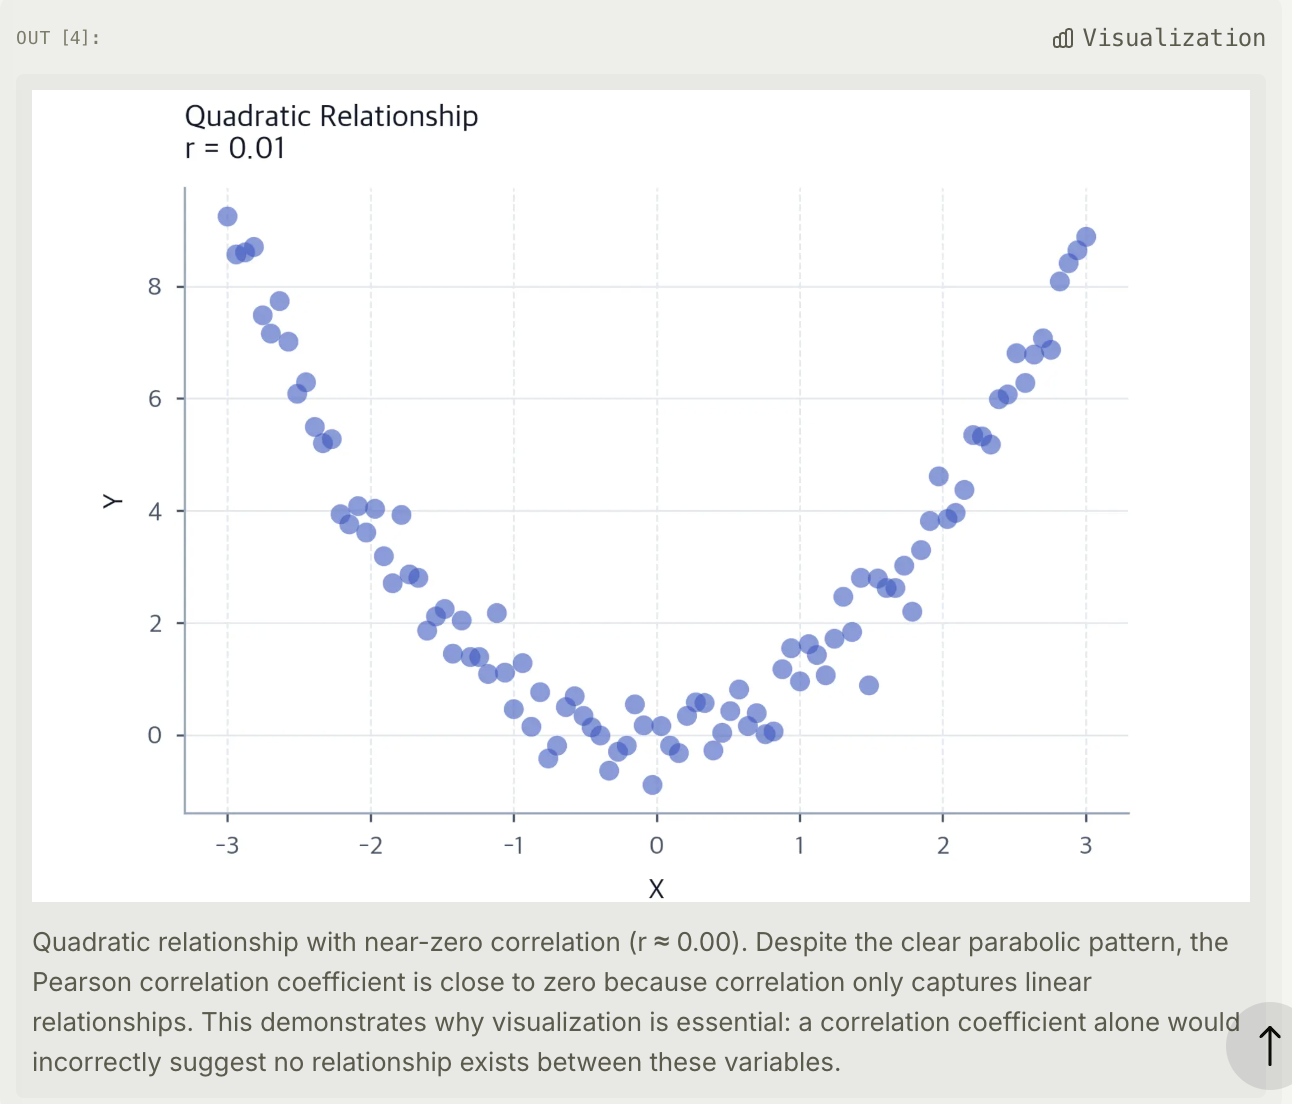


## 5. Simple Linear Regression: Modeling Relationships

While correlation measures the strength of a linear relationship, regression goes further by modeling the relationship explicitly. Simple linear regression fits a line through the data to predict a dependent variable 
$Y$ from an independent variable 
$X$. This line represents the best linear approximation of how 
$Y$ changes as 
$X$ changes.


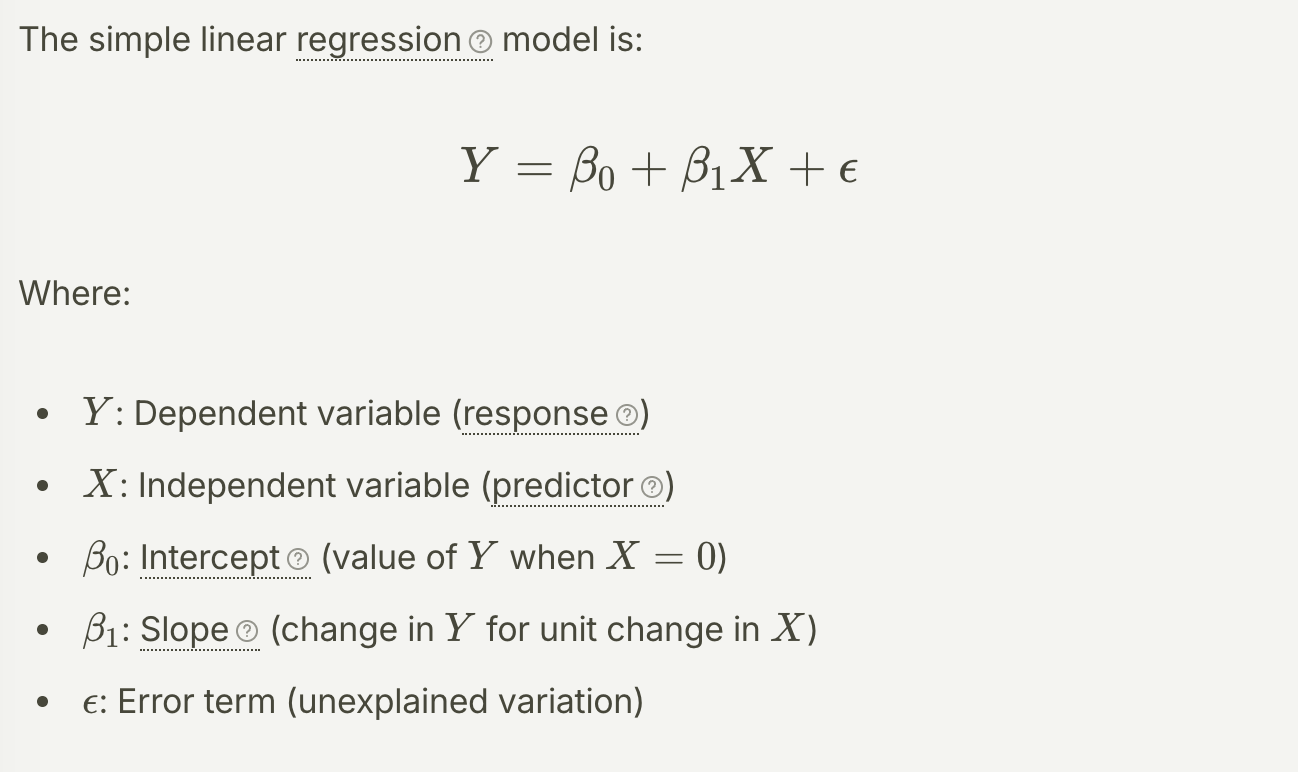


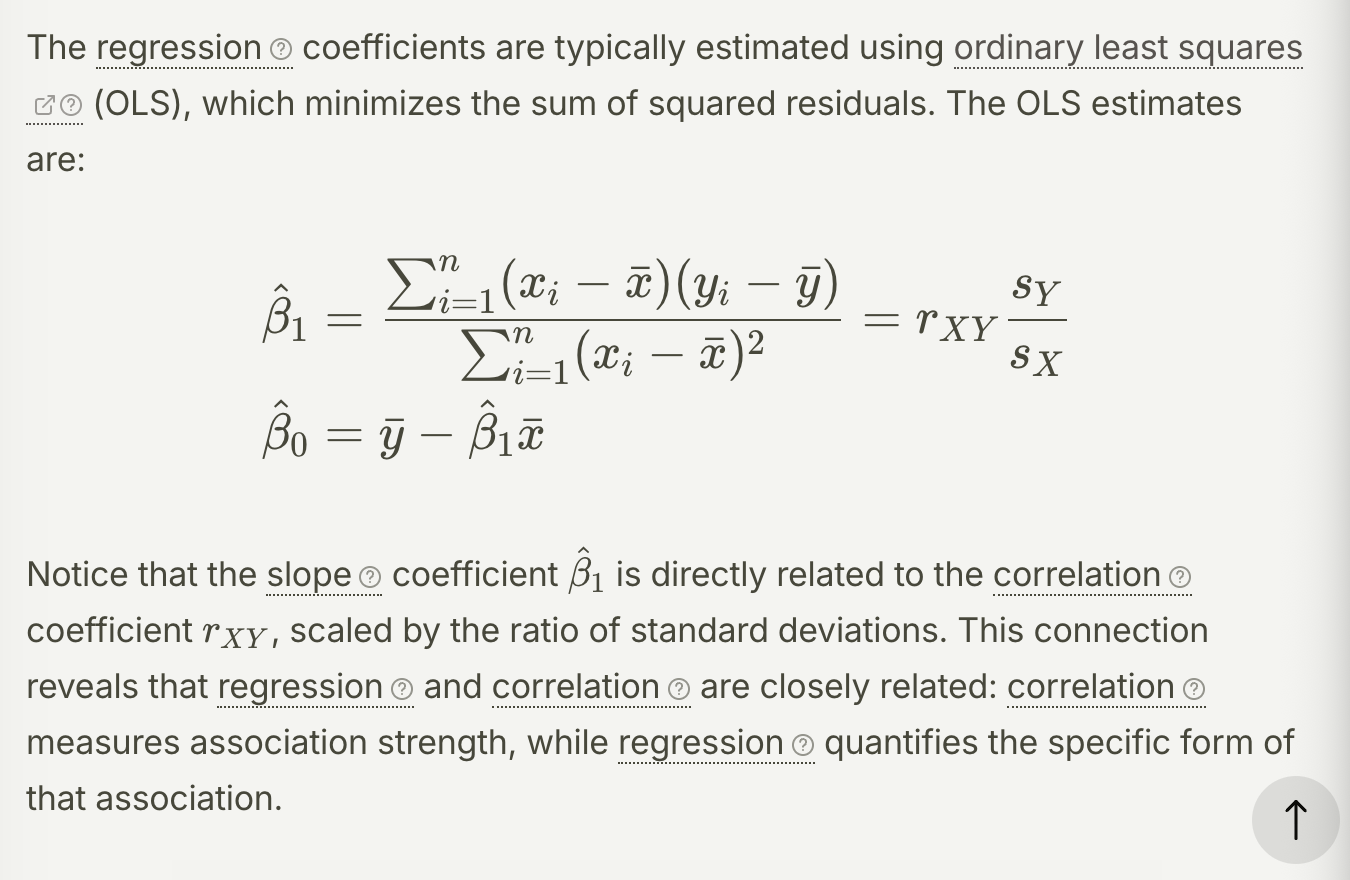


The regression line gives several useful capabilitiues. 
1. First it allows prediction: Given a new value of $X$ , we can predict the expected value of $Y$ using $\hat{Y}= \hat{\beta}_0 + \hat{\beta}_1 * X$.
2. Second the slope of coefficient $\hat{\beta}_1 $ quantifies the average change in $Y$  associate with one unit change of $X$.
3. Third the regression framework allows for statistical inference : we can test whether the relationship is statistically significant and construct confidence intervals for the coefficients.

The following example demonstrates a simple linear regression fit to data with a clear linear relationship. The regression line captures the average tendency of Y to increase with X, while the residuals represent the unexplained variation around this trend.

Fitted equation: Y = 1.17 + 2.13X


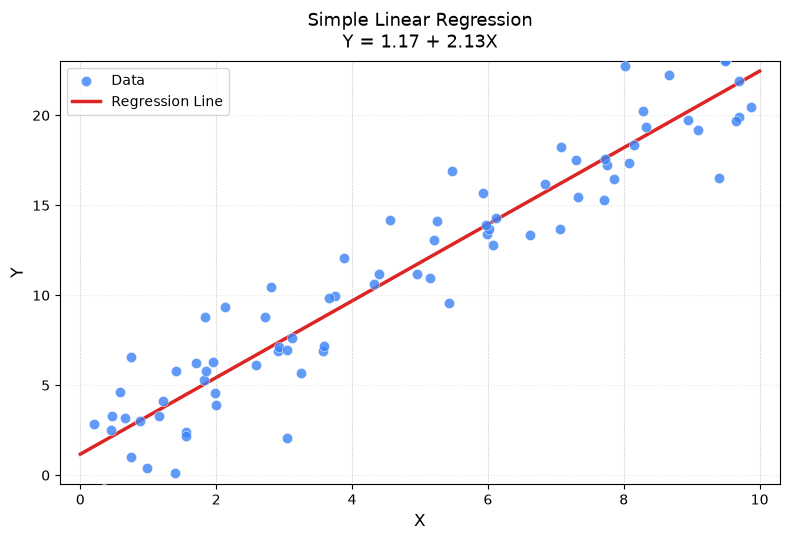

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

np.random.seed(42)

# -------------------------------------------------
# Generate data that follows approximately Y = 1.65 + 2.03X
# -------------------------------------------------
n = 80
x = np.random.uniform(0, 10, n)
y = 1.65 + 2.03 * x + np.random.normal(0, 2.2, n)   # noise level chosen to match the spread

# Fit the regression (so the displayed equation is exact)
model = LinearRegression()
model.fit(x.reshape(-1, 1), y)
intercept = model.intercept_
slope = model.coef_[0]

print(f"Fitted equation: Y = {intercept:.2f} + {slope:.2f}X")

# -------------------------------------------------
# Plot
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5.5))

# Data points
ax.scatter(x, y, c='#3b82f6', s=55, alpha=0.8, edgecolors='white',
           linewidth=0.4, label='Data', zorder=3)

# Regression line
x_line = np.linspace(0, 10, 100)
y_line = intercept + slope * x_line
ax.plot(x_line, y_line, color='#dc2626', linewidth=2.5, label='Regression Line', zorder=2)

# Styling to match the original
ax.set_xlim(-0.3, 10.3)
ax.set_ylim(-0.5, 23)
ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('Y', fontsize=12)
ax.set_title(f'Simple Linear Regression\nY = {intercept:.2f} + {slope:.2f}X',
             fontsize=13, pad=10)

ax.grid(True, alpha=0.3, linestyle=':')
ax.legend(loc='upper left', fontsize=10, frameon=True)

# Light vertical reference lines
for v in range(0, 11, 2):
    ax.axvline(v, color='gray', linestyle=':', linewidth=0.6, alpha=0.4)

plt.savefig("Plots/LineaRegression.png", dpi=150)
plt.tight_layout()
plt.show()

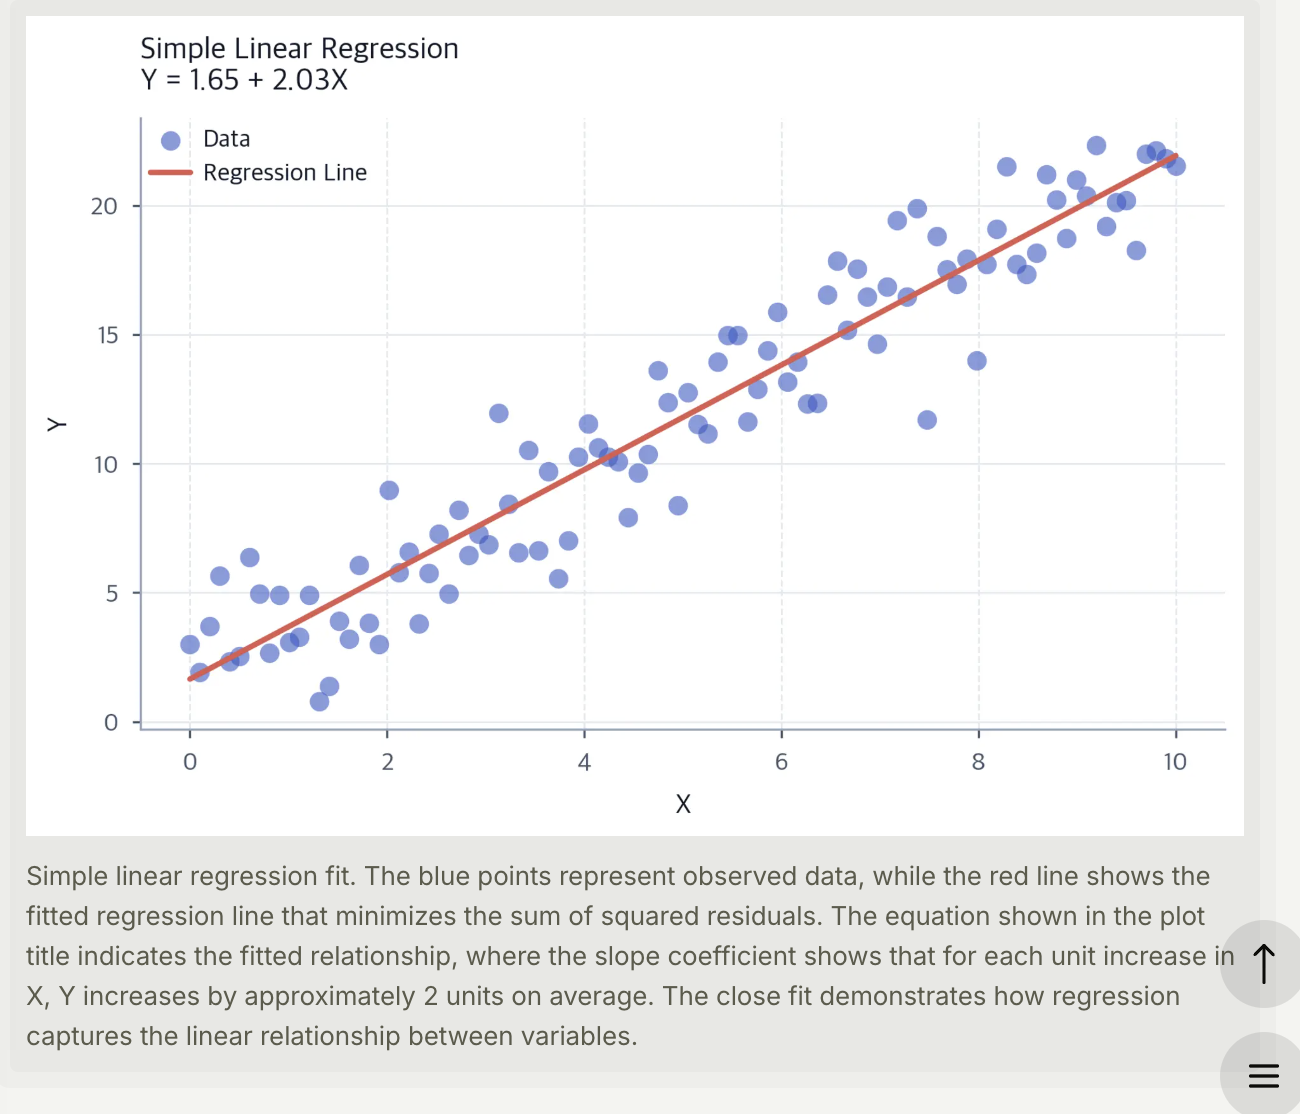

Understanding what regression optimizes helps build intuition for how the method works. The "least squares" criterion means we're finding the line that minimizes the sum of squared vertical distances from points to the line. These vertical distances are called residuals, and they represent the prediction errors. The following visualization shows these residuals explicitly and illustrates what the regression line accomplishes.

Fitted line: Y = 2.41 + 1.89X


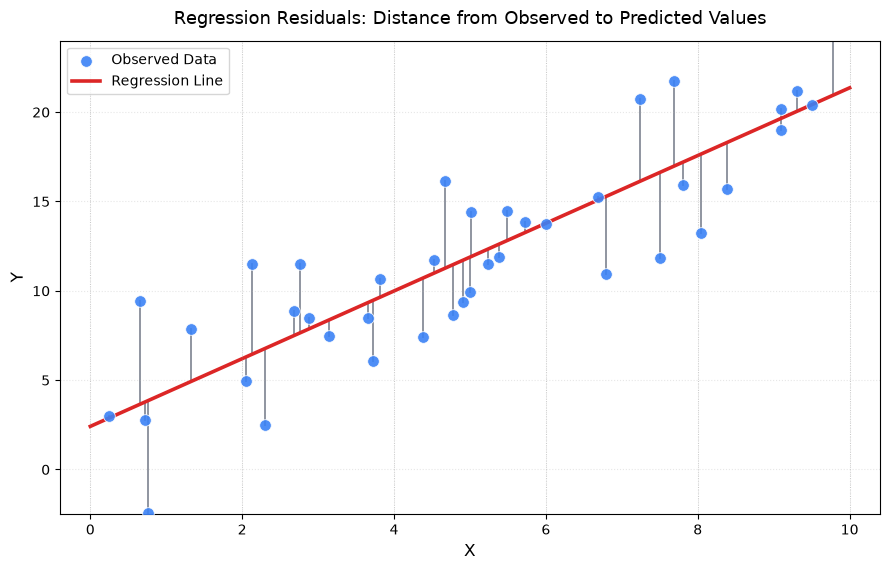

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

np.random.seed(7)

# -------------------------------------------------
# Generate data
# -------------------------------------------------
n = 40
x = np.random.uniform(0, 10, n)
y = 1.8 + 2.05 * x + np.random.normal(0, 2.8, n)

# Fit OLS regression
model = LinearRegression()
model.fit(x.reshape(-1, 1), y)
y_pred = model.predict(x.reshape(-1, 1))

intercept = model.intercept_
slope = model.coef_[0]
print(f"Fitted line: Y = {intercept:.2f} + {slope:.2f}X")

# -------------------------------------------------
# Plot
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5.8))

# Residual lines (vertical gray segments)
for xi, yi, ypi in zip(x, y, y_pred):
    ax.plot([xi, xi], [yi, ypi], color='#6b7280', linewidth=1.4, alpha=0.75, zorder=1)

# Observed data points
ax.scatter(x, y, c='#3b82f6', s=70, alpha=0.9, edgecolors='white',
           linewidth=0.6, label='Observed Data', zorder=3)

# Regression line
x_line = np.linspace(0, 10, 100)
y_line = intercept + slope * x_line
ax.plot(x_line, y_line, color='#dc2626', linewidth=2.6, label='Regression Line', zorder=2)

# Styling
ax.set_xlim(-0.4, 10.4)
ax.set_ylim(-2.5, 24)
ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('Y', fontsize=12)
ax.set_title('Regression Residuals: Distance from Observed to Predicted Values',
             fontsize=13, pad=12)

ax.grid(True, alpha=0.3, linestyle=':')
ax.legend(loc='upper left', fontsize=10, frameon=True)

# Light vertical reference lines
for v in range(0, 11, 2):
    ax.axvline(v, color='gray', linestyle=':', linewidth=0.6, alpha=0.4)

plt.savefig("Plots/ResidualError.png", dpi=150)
plt.tight_layout()
plt.show()

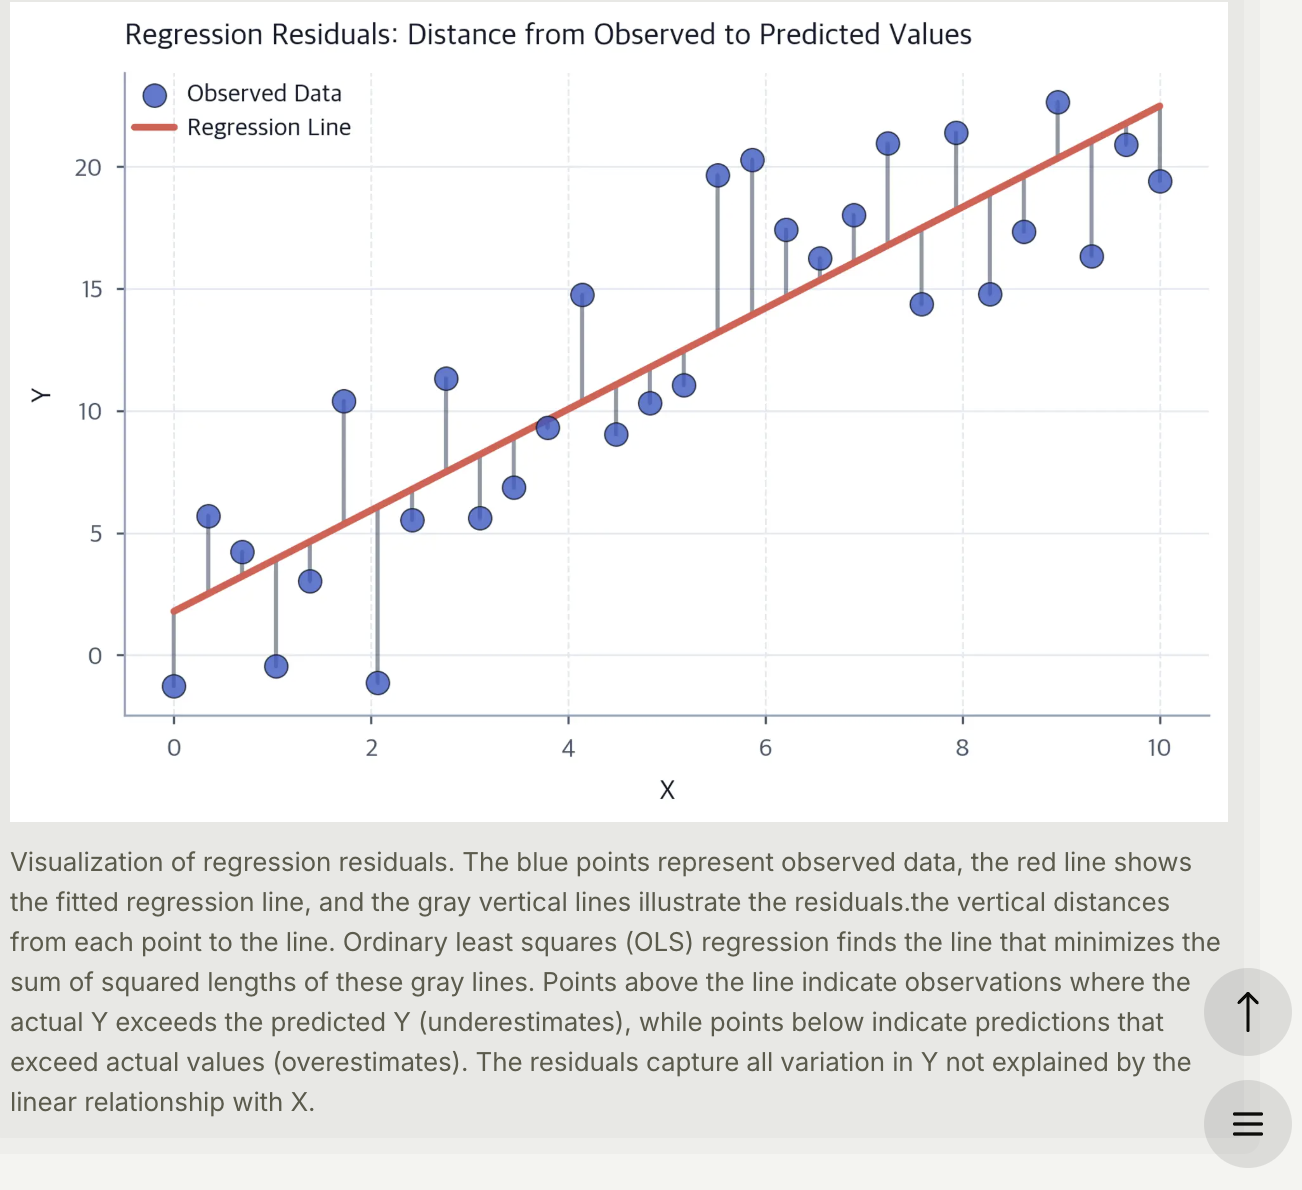

## 6. Multiple Linear Regression: Multiple Indicators

Real-world phenomena typically depend on multiple factors rather than a single predictor. Multiple linear regression extends simple regression to model the relationship between a dependent variable and multiple independent variables simultaneously. This approach allows us to estimate the effect of each predictor while controlling for the others.

The multiple linear regression model is:

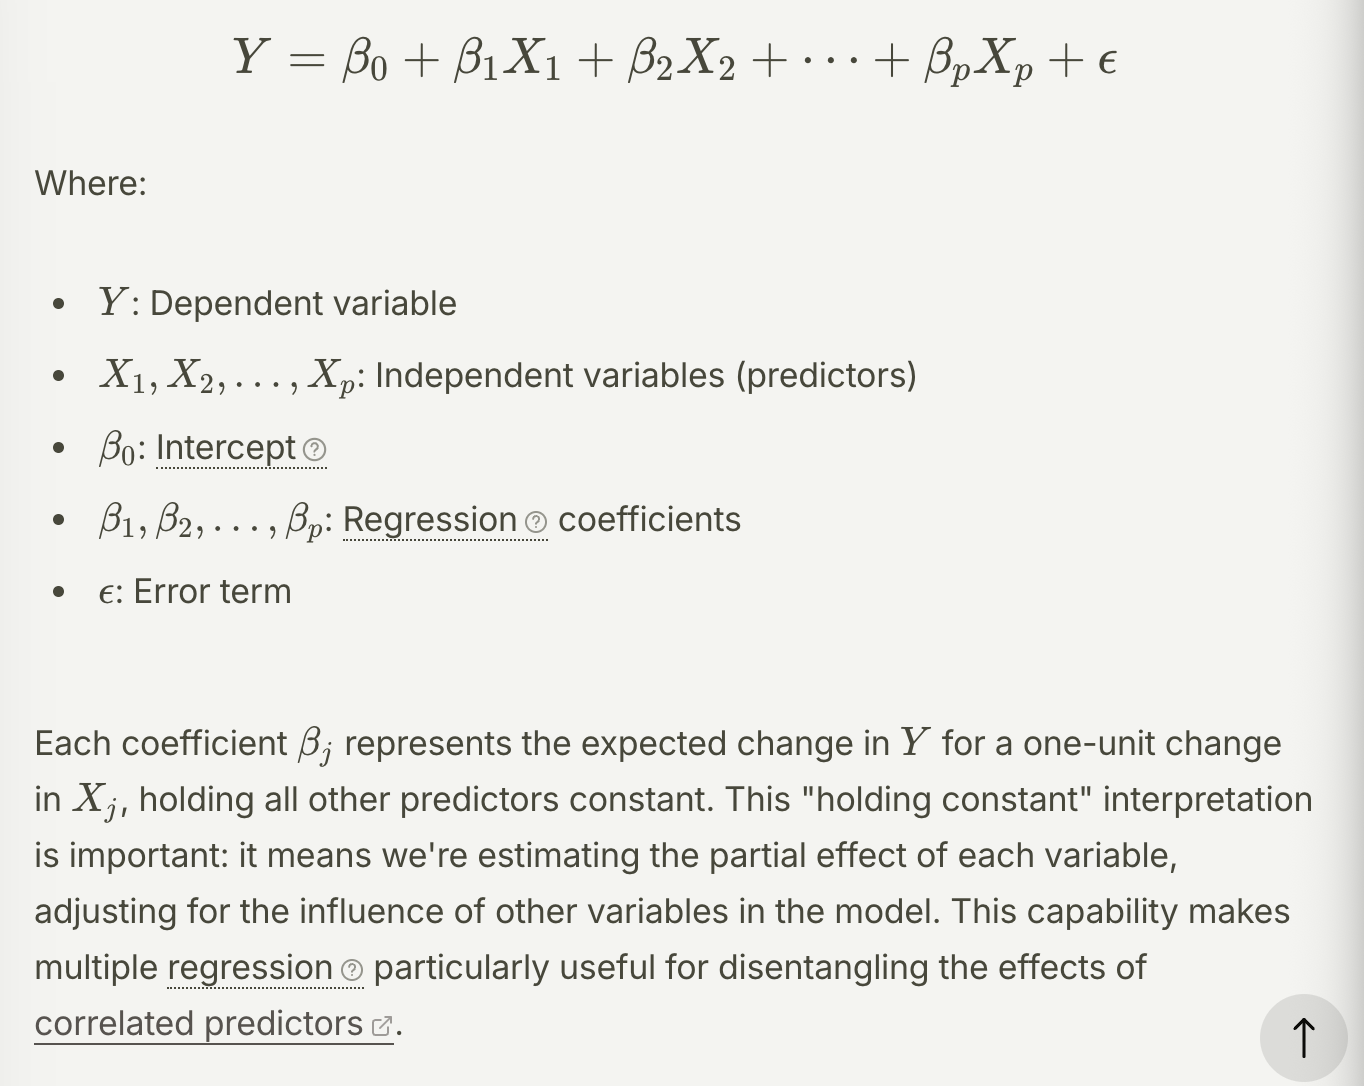
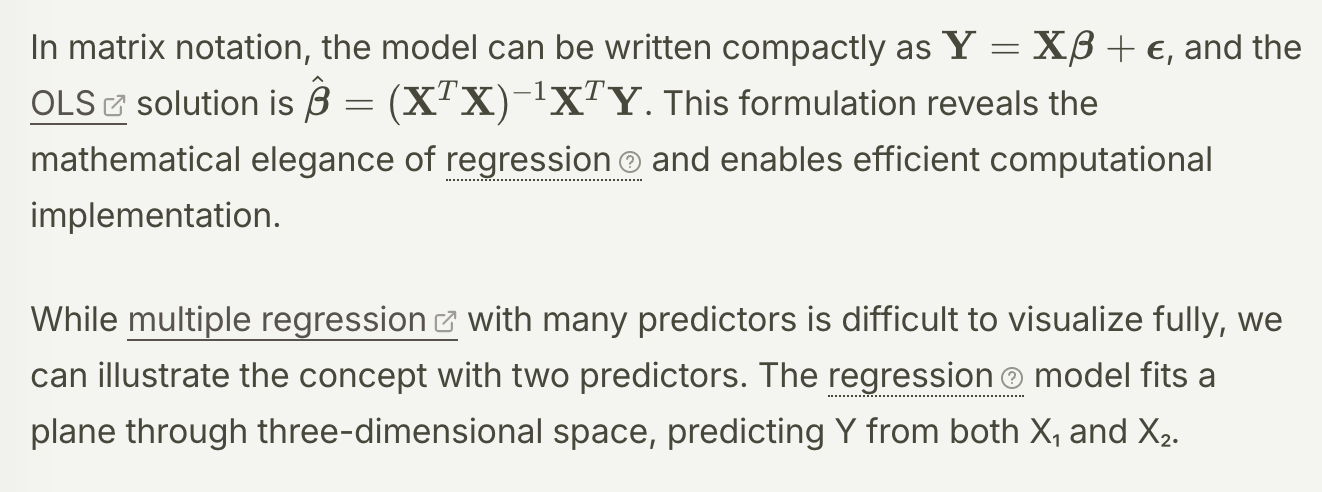



Fitted equation: Y = 3.67 + 1.92X1 + 1.49X2


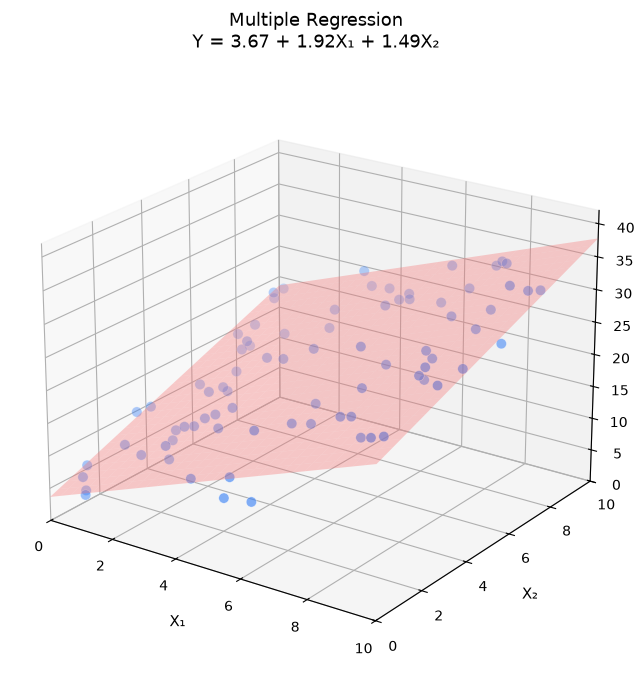

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression

np.random.seed(42)

# -------------------------------------------------
# Generate synthetic data
# -------------------------------------------------
n = 80
X1 = np.random.uniform(0, 10, n)
X2 = np.random.uniform(0, 10, n)
Y  = 2.82 + 1.93 * X1 + 1.64 * X2 + np.random.normal(0, 2.5, n)

# Fit multiple linear regression
X = np.column_stack([X1, X2])
model = LinearRegression()
model.fit(X, Y)

intercept = model.intercept_
coef1, coef2 = model.coef_
print(f"Fitted equation: Y = {intercept:.2f} + {coef1:.2f}X1 + {coef2:.2f}X2")

# -------------------------------------------------
# Create the regression plane
# -------------------------------------------------
x1_surf = np.linspace(0, 10, 30)
x2_surf = np.linspace(0, 10, 30)
X1_surf, X2_surf = np.meshgrid(x1_surf, x2_surf)
Y_surf = intercept + coef1 * X1_surf + coef2 * X2_surf

# -------------------------------------------------
# 3D Plot
# -------------------------------------------------
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Observed data points
ax.scatter(X1, X2, Y, c='#3b82f6', s=55, alpha=0.85,
           edgecolors='white', linewidth=0.4, label='Observed Data', depthshade=True)

# Regression plane
ax.plot_surface(X1_surf, X2_surf, Y_surf, color='#f87171', alpha=0.35,
                edgecolor='none', shade=True)

# Labels and title
ax.set_xlabel('X₁', fontsize=11, labelpad=8)
ax.set_ylabel('X₂', fontsize=11, labelpad=8)
ax.set_zlabel('Y', fontsize=11, labelpad=8)
ax.set_title(f'Multiple Regression\nY = {intercept:.2f} + {coef1:.2f}X₁ + {coef2:.2f}X₂',
             fontsize=13, pad=15)

# Axis limits to match the figure
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_zlim(0, 42)

# Viewing angle similar to the original
ax.view_init(elev=22, azim=-55)

plt.savefig("Plots/Multiple_Regression.png", dpi=150)
plt.tight_layout()
plt.show()

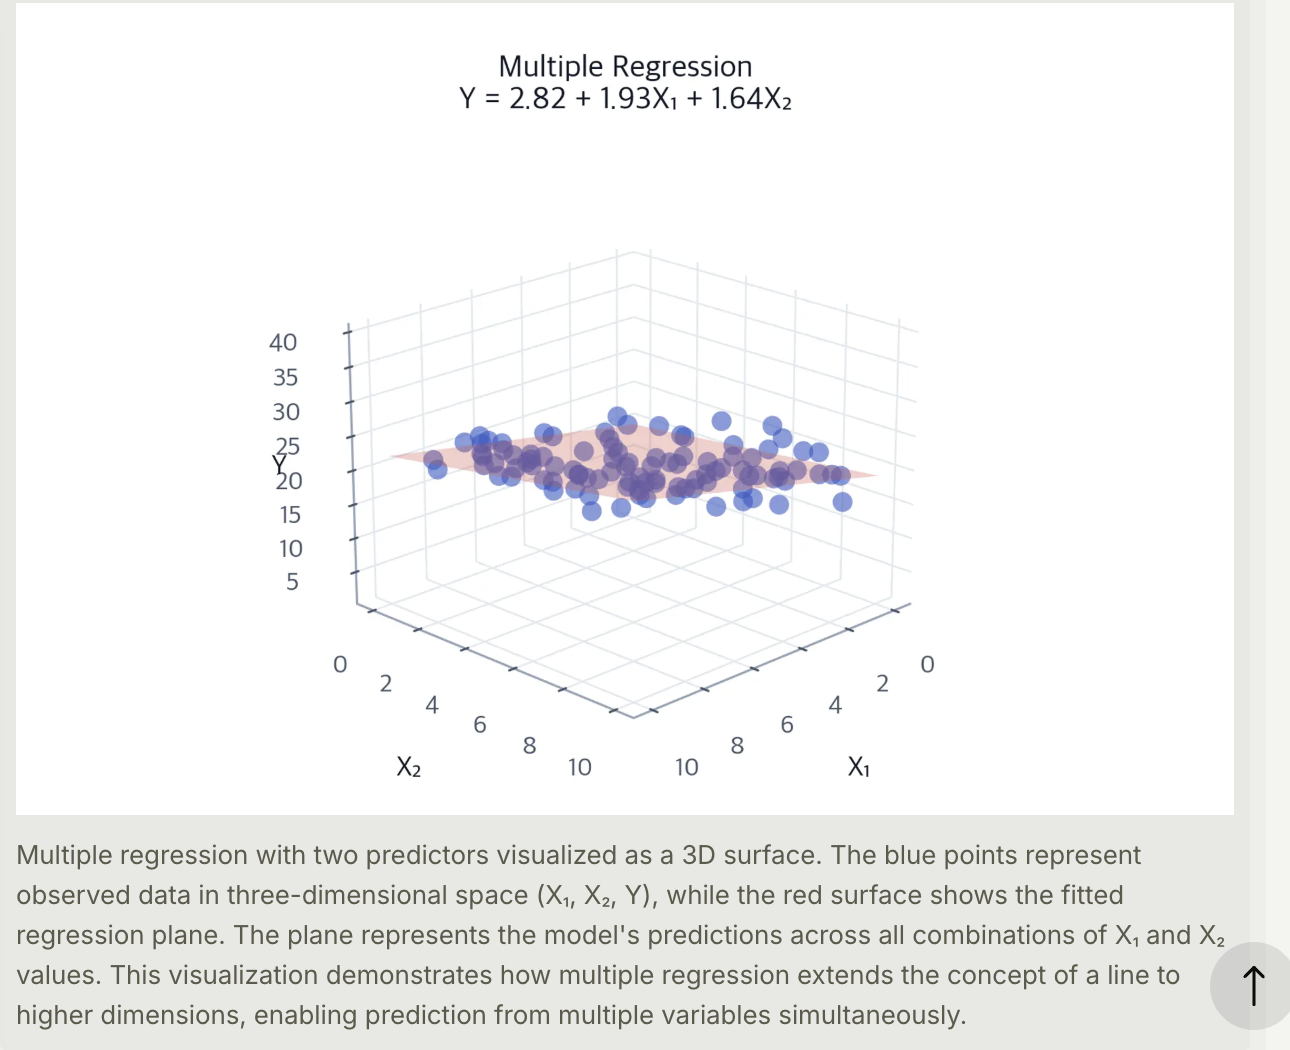

## 7.Causation vs. Correlation: A Critical Distinction

Perhaps the most important lesson in studying variable relationships is understanding the difference between correlation and causation. Correlation tells us that two variables move together, but it does not tell us whether one causes the other. This distinction is fundamental to sound statistical reasoning and prevents serious errors in interpretation and decision-making.

When we observe a correlation between variables 
X and 
Y, several scenarios could explain the relationship. 

1. First, 
X might cause 
Y.
2.  Second, 
Y might cause 
X (reverse causation)
3. Third, both
X and 
Y might be caused by a third variable 
Z that we haven't measured (confounding).
4. Fourth, the correlation might be purely coincidental, especially when examining many variable pairs (spurious correlation).


Without additional information or careful study design, we cannot determine which scenario applies.

Classic examples illustrate the danger of conflating correlation with causation. Ice cream sales and drowning deaths are positively correlated across months, but neither causes the other: both increase during summer when weather is warm. The number of firefighters at a scene correlates with fire damage, but firefighters don't cause damage: larger fires require more firefighters and cause more damage. These examples seem obvious, but similar logical errors occur frequently in data analysis when domain knowledge is insufficient or causal reasoning is neglected.

Establishing causation requires more than observing correlation. Randomized controlled experiments give the gold standard by randomly assigning subjects to treatment and control groups. When experiments are infeasible, causal inference methods such as instrumental variables, regression discontinuity designs, or difference-in-differences can help under specific assumptions. Longitudinal data showing that changes in 
X precede changes in 
Y give suggestive evidence,though temporal precedence alone doesn't prove causation. Strong domain theory explaining a plausible causal mechanism strengthens causal claims.

This distinction has practical consequences. In policy decisions, prescribing interventions based on correlations without understanding causation can be ineffective or harmful. In business, optimizing for correlated metrics rather than causal drivers may waste resources. In science, publishing correlations as causal claims erodes credibility and misinforms the public. Approaching correlations with healthy skepticism and asking "What other factors might explain this relationship?" and "What evidence would demonstrate causation rather than mere association?" helps avoid these pitfalls.

The following example illustrates how a confounding variable can create a spurious correlation between two variables that have no direct causal relationship.

r(X,Y) = 0.96
r(Z,X) = 0.98
r(Z,Y) = 0.98


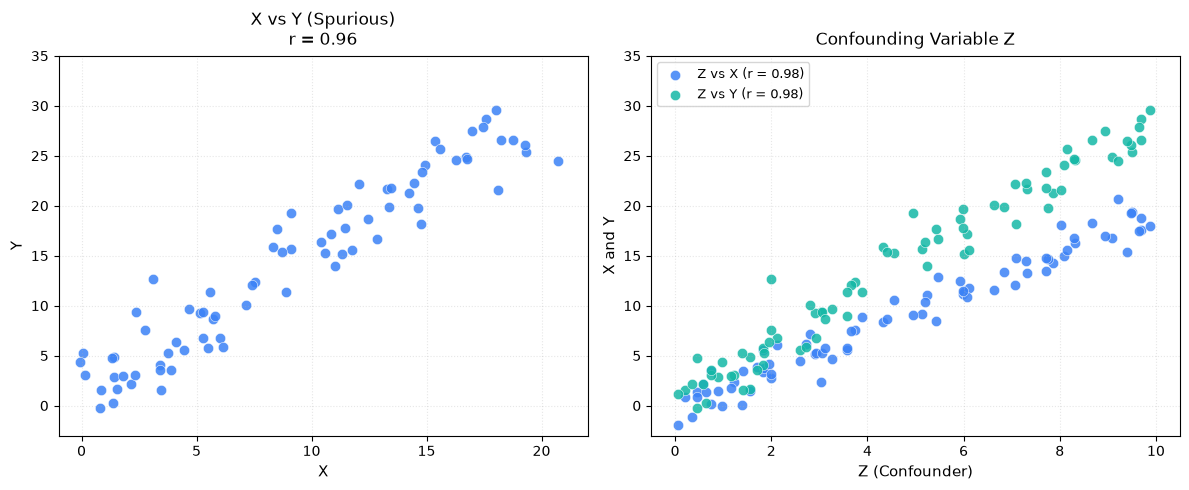

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

np.random.seed(42)

# -------------------------------------------------
# Generate data with a confounder Z
# -------------------------------------------------
n = 80
Z = np.random.uniform(0, 10, n)

# Both X and Y are driven by Z (plus a little independent noise)
X = 1.9 * Z + np.random.normal(0, 1.3, n)
Y = 2.9 * Z + np.random.normal(0, 1.8, n)

# Correlations
r_xy, _ = pearsonr(X, Y)
r_zx, _ = pearsonr(Z, X)
r_zy, _ = pearsonr(Z, Y)

print(f"r(X,Y) = {r_xy:.2f}")
print(f"r(Z,X) = {r_zx:.2f}")
print(f"r(Z,Y) = {r_zy:.2f}")

# -------------------------------------------------
# Create the two-panel figure
# -------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# ----- Left panel: Spurious X vs Y -----
ax1.scatter(X, Y, c='#3b82f6', s=55, alpha=0.85, edgecolors='white', linewidth=0.4)
ax1.set_xlabel('X', fontsize=11)
ax1.set_ylabel('Y', fontsize=11)
ax1.set_title(f'X vs Y (Spurious)\nr = {r_xy:.2f}', fontsize=12, pad=8)
ax1.grid(True, alpha=0.3, linestyle=':')
ax1.set_xlim(-1, 22)
ax1.set_ylim(-3, 35)

# ----- Right panel: Confounder Z -----
ax2.scatter(Z, X, c='#3b82f6', s=55, alpha=0.85, edgecolors='white',
            linewidth=0.4, label=f'Z vs X (r = {r_zx:.2f})')
ax2.scatter(Z, Y, c='#14b8a6', s=55, alpha=0.85, edgecolors='white',
            linewidth=0.4, label=f'Z vs Y (r = {r_zy:.2f})')

ax2.set_xlabel('Z (Confounder)', fontsize=11)
ax2.set_ylabel('X and Y', fontsize=11)
ax2.set_title('Confounding Variable Z', fontsize=12, pad=8)
ax2.grid(True, alpha=0.3, linestyle=':')
ax2.legend(loc='upper left', fontsize=9, frameon=True)
ax2.set_xlim(-0.5, 10.5)
ax2.set_ylim(-3, 35)

plt.savefig("Plots/CausionVsCorrelation.png", dpi=150)
plt.tight_layout()
plt.show()

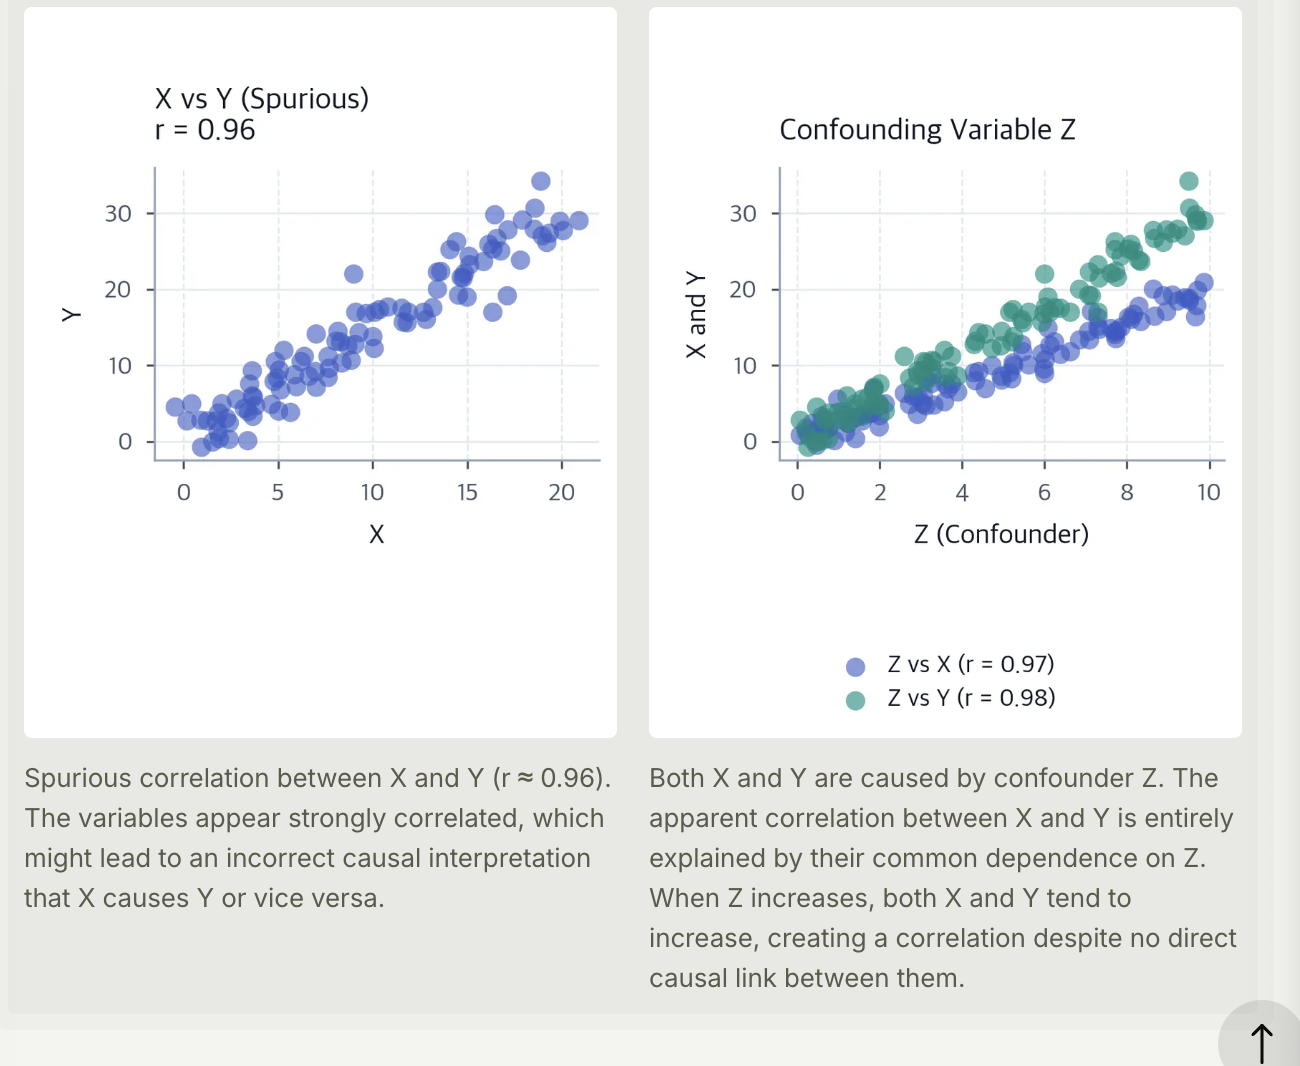

## 8. Practical Applicaitons
Understanding variable relationships is part of nearly every data science application. In exploratory data analysis, correlation matrices and scatter plot matrices reveal patterns in multivariate datasets, guiding feature selection and hypothesis generation. Identifying which variables correlate strongly with the target variable helps prioritize modeling efforts and can reveal unexpected relationships worth investigating.

In predictive modeling, regression is both a standalone algorithm and a component of more complex methods. Linear regression gives interpretable baseline models whose coefficients quantify the strength and direction of predictor effects. Even when more sophisticated algorithms like random forests or neural networks ultimately give better predictions, regression analysis helps understand which features matter most and whether relationships are approximately linear or highly non-linear.

n A/B testing and causal inference, distinguishing correlation from causation is essential. Randomized experiments enable causal conclusions by ensuring that treatment assignment is independent of potential confounders. Observational studies require careful attention to confounding variables and may employ techniques like propensity score matching or instrumental variables to approximate causal estimates from correlational data.

In quality control and process monitoring, correlation analysis identifies which process variables affect product quality, enabling targeted interventions. In finance, correlation between assets informs portfolio diversification strategies. In epidemiology, identifying correlates of disease helps generate hypotheses about risk factors, though establishing causation requires additional evidence from controlled studies or natural experiments.

## 9. Limiations and Considerations
Correlation and regression methods rest on important assumptions that should be verified in practice. Linearity is perhaps the most fundamental assumption: these methods measure and model linear relationships, so they may fail to capture non-linear patterns. Visualizing relationships before computing correlations or fitting regression models helps ensure linearity is plausible. If relationships are non-linear, transformations like logarithms or polynomials may help, or alternative methods like generalized additive models may be more appropriate.

Outliers can dramatically influence correlation and regression estimates because both methods involve squared deviations. A single extreme observation can inflate or deflate correlation coefficients substantially and can rotate regression lines away from the bulk of the data. Some methods downweight outliers, but understanding why outliers occur and whether they represent valid data points is important before deciding how to handle them.

The following visualization demonstrates just how sensitive correlation coefficients are to outliers. A single extreme point can completely change the correlation from near zero to strongly negative.

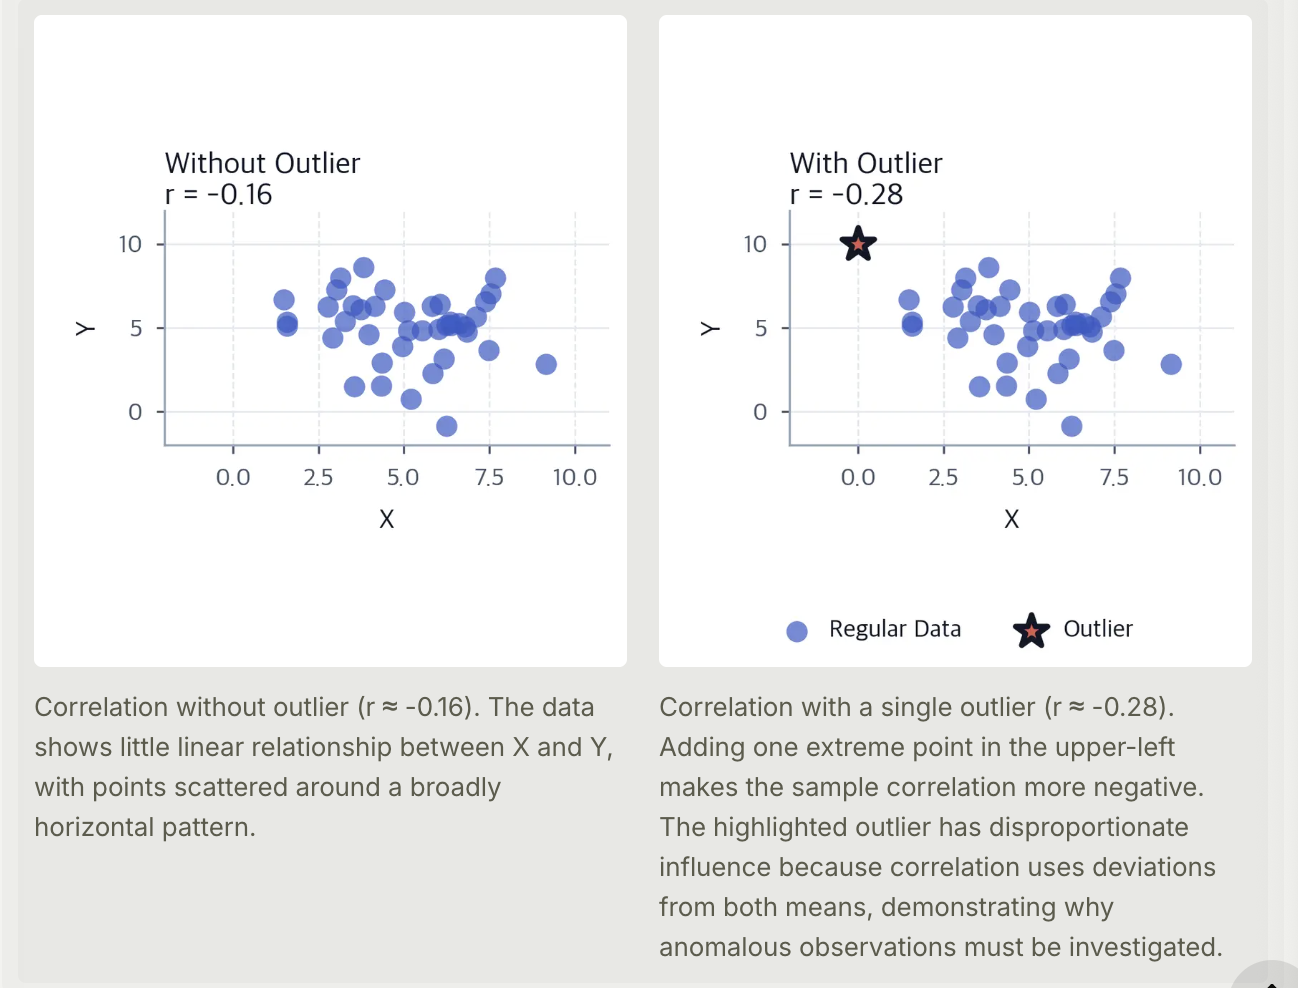

Regression additionally assumes that errors are independent, identically distributed, and have constant variance (homoscedasticity). When these assumptions are violated (for example, when errors are correlated across time or when variance increases with the predicted value), standard errors and confidence intervals become unreliable. Residual diagnostics including plots of residuals versus fitted values help detect such violations and guide corrective actions like transformation or switching to weighted regression.

Sample size affects the reliability of correlation and regression estimates. Small samples yield imprecise estimates with wide confidence intervals, and correlations can appear strong due to chance even when no relationship exists in the population. Statistical significance testing helps distinguish real relationships from sampling variability, but practical significance also matters: a statistically significant but tiny correlation may have little practical value despite low p-values in large datasets.

Finally, correlation and regression describe associations in observed data but do not, by themselves, establish causation. Claims about causal relationships require additional evidence from experimental manipulation, temporal ordering, elimination of confounders, or strong theoretical justification. Interpreting regression coefficients as causal effects requires study designs that support such interpretation, such as randomized experiments or appropriate causal inference methods.

## Summary

Understanding relationships between variables forms the foundation of statistical analysis and data science. Covariance and correlation quantify how variables move together, with correlation providing a standardized measure that ranges from -1 to +1 regardless of units. These metrics reveal the strength and direction of linear associations, guiding exploratory analysis and feature selection.

Regression extends correlation by explicitly modeling relationships, enabling prediction and quantifying how changes in predictors associate with changes in the response. Simple linear regression models the relationship between two variables, while multiple regression accommodates many predictors simultaneously and estimates partial effects while controlling for other variables. The regression framework provides both point predictions and statistical inference about the nature and significance of relationships.

Perhaps most critically, correlation does not imply causation. Observed associations can arise from direct causal effects, reverse causation, confounding variables, or pure chance. Establishing causation requires careful study design, often involving randomization or sophisticated observational methods. Conflating correlation with causation leads to flawed conclusions and misguided decisions, making this distinction one of the most important lessons in data science.

Covariance and correlation, together with regression, give the basis for understanding variable relationships. Used thoughtfully with attention to assumptions and limitations, they enable useful insights into complex data. Visualizing your data, verifying assumptions, considering alternative explanations for observed patterns, and recognizing that statistical associations rarely tell the complete story on their own are all important practices for sound analysis.